- Here we analyze how the structure function changes when modifying the 'Turbustat' versions for sysnthetic:
    - two-dimensional (https://turbustat.readthedocs.io/en/latest/api/turbustat.simulator.make_extended.html#turbustat.simulator.make_extended)
    - and three-dimensional fields (https://turbustat.readthedocs.io/en/latest/api/turbustat.simulator.make_3dfield.html#make-3dfield)
- Also, the recover the turbulent paramters throught a fit.


In [1]:
import time
start_time=time.time()

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from spectral_cube import SpectralCube
from turbustat.simulator import make_ppv
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
from skimage.util import random_noise
import corner
import ci_results_compiler


# Add path to py_modules 

sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

from turb_utils import make_extended, make_3dfield
import strucfunc
import bfunc
import bplot

In [3]:
# Physical parameters

N     = 256
ra    = N / 16 # Artificial correlation length
m2D   = 0.85 # for recovering m as 1.00 in the projected field (ND + m2D)
m3D_1 = 0.30 # for recovering m as 1.00 in the projected field (ND + m3D)
m3D_2 = 0.55 # for recovering m as 1.00 in the projected field (ND + m3D)

# Modification

``` python
    if ellip < 1:
        # Apply a rotation and scale the x-axis (ellip).
        costheta = np.cos(theta)
        sintheta = np.sin(theta)

        xprime = ellip * (xx * costheta - yy * sintheta)
        yprime = xx * sintheta + yy * costheta

        rr2 = xprime ** 2 + yprime ** 2

        rr = rr2 ** 0.5
        # Also save circular version to use with correlation_length <-----------
        rcirc = np.hypot(xx, yy)   <-----------
        rcirc[rcirc == 0.0] = np.nan  <-----------
    else:
        # Circular whenever ellip == 1
        rr = (xx ** 2 + yy ** 2) ** 0.5

    # flag out the bad point to avoid warnings
    rr[rr == 0] = np.nan

    if correlation_length is not None:     <-----------
        # Taper the power spectrum at large separations (low spatial   <-----------
        # frequencies) so that the field is uncorrelated at the <-----------
        # largest scales. <-----------
        #
        # rcirc is spatial frequency: 1 / r, measured in pixels <-----------
        output *= np.exp(-1.0 / (2 * np.pi * rcirc * correlation_length)) <-----------
```


$$e^{-\dfrac{1}{2 \pi k r_0}}$$


# Fake velocity cubes velocity and emissivity


- Generate simulated emissivity and velocity cubes
- Integrate them to get simulated intensity, velocity (and sigma) maps

In [15]:
## Sie E = 0

## Sie E = 1

In [4]:
sig_E = 1 

In [5]:
# Non-Tapered
## Emissivity fluctuations


density = make_3dfield(N, 
    powerlaw            = 3.0 + m3D_1, 
#    correlation_length  = r0,  
    amp                 = 1.0,
    ellip               = 0.5,
    theta               = 45,
    randomseed          = 1939_05_01) * u.cm**-3 

density = (density-density.mean())/density.std()

emissivity = np.exp(sig_E * density)* u.cm**-3


# Velocity fluctuations

velocity = make_3dfield(N,
    powerlaw           =3.0 + m3D_1,
#    correlation_length = r0,  
    ellip              = 0.5,
    theta              = 45,
    randomseed         = 1894_04_25)* u.km / u.s  

# Making PPV cube

cube_hdu = make_ppv(velocity, emissivity, los_axis=0,
                    T=10000 * u.K, chan_width=0.5 * u.km / u.s,
                    v_min=-20 * u.km / u.s,
                    v_max=20 * u.km / u.s)  

cube0 = SpectralCube.read(cube_hdu)  

In [7]:
# Tapered
## Emissivity fluctuations

density = make_3dfield(N, 
    powerlaw            = 3.0 + m3D_1, 
    correlation_length  = ra,  
    amp                 = 1.0,
    ellip               = 0.5,
    theta               = 45,
    randomseed          = 1939_05_01) * u.cm**-3 

density = (density-density.mean())/density.std()

emissivity = np.exp(sig_E * density)* u.cm**-3


# Velocity fluctuations

velocity = make_3dfield(N,
    powerlaw           =3.0 + m3D_1,
    correlation_length = ra,  
    ellip              = 0.5,
    theta              = 45,
    randomseed         = 1894_04_25)* u.km / u.s   

# Making PPV cube

cube_hdu = make_ppv(velocity, emissivity, los_axis=0,
                    T=10000 * u.K, chan_width=0.5 * u.km / u.s,
                    v_min=-20 * u.km / u.s,
                    v_max=20 * u.km / u.s)  

cube = SpectralCube.read(cube_hdu)  

In [8]:
vmap_ = cube.moment1().value
vmap0_ = cube0.moment1().value

signorm_ = vmap_.std()
vmap_ /= signorm_

signorm0_ = vmap0_.std()
vmap0_ /= signorm0_

print(signorm_, signorm0_)

0.1757869623110296 0.39981058410470105


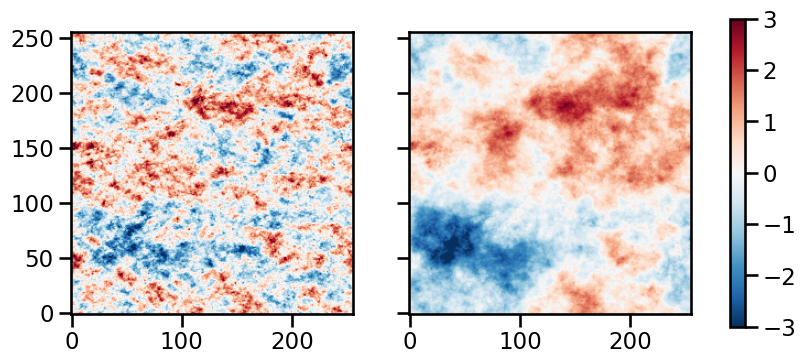

In [9]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap_, **imshow_kwds)
im = axx.imshow(vmap0_, **imshow_kwds)
fig.colorbar(im, ax=[ax, axx])

In [18]:
sf_ = strucfunc.strucfunc_numba_parallel(vmap_, dlogr=0.05)
sf0_ = strucfunc.strucfunc_numba_parallel(vmap0_, dlogr=0.05)

C:\Users\ZAINTEL2\Dropbox\GitHub\fake_maps\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\fake_maps\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


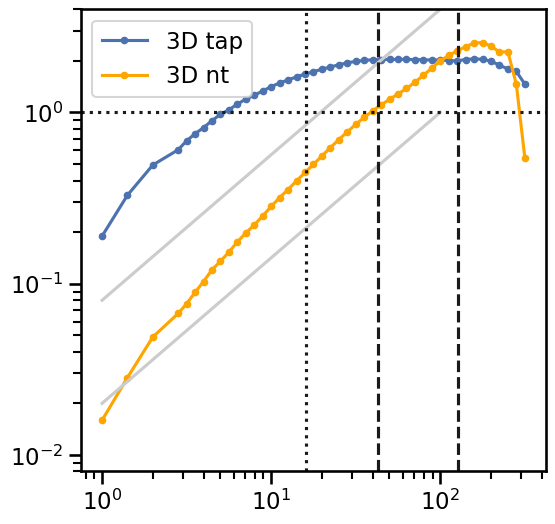

In [21]:
fig, ax = plt.subplots(
    figsize=(6, 6),
)
mask = sf_["N pairs"] > 0
r_ = 10 ** sf_["log10 r"][mask]
B_ = sf_["Unweighted B(r)"][mask]
B0_ = sf0_["Unweighted B(r)"][mask]

ax.plot(r_, B_, marker=".", color = 'b', label = '3D tap')
ax.plot(r_, B0_, marker=".", color = 'orange', label = '3D nt')
#ax.plot(r, B, marker="x", color = 'b', label = '2D tap')
#ax.plot(r, B0, marker="x", color = 'orange', label = '2D nt')

rgrid = np.logspace(0.0, 2.0)

for scale in 0.02, 0.08:
    ax.plot(rgrid, scale * rgrid ** m2D, color="0.8")

ax.axhline(1.0, color="k", linestyle="dotted")
ax.axvline(ra, color="k", linestyle="dotted")
ax.axvline(N / 2, color="k", linestyle="dashed")
ax.axvline(N / 6, color="k", linestyle="dashed")
ax.set(
    xscale="log",
    yscale="log",
    ylim=[8e-3, 4],
)

ax.legend()


In [ ]:
print("--- %s seconds ---" % (time.time()-start_time))